# Uber Supply-Demand Gap Analysis
### Objective: Identify time-based supply-demand mismatches.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Uber Request Datas.xlsx")
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1,Trip Completed,11-07-16-11:51,11-07-16-13:00
1,867,Airport,1,Trip Completed,11-07-16-17:57,11-07-16-18:47
2,1807,City,1,Trip Completed,12-07-16-09:17,12-07-16-09:58
3,2532,Airport,1,Trip Completed,12-07-16-21:08,12-07-16-22:03
4,3112,City,1,Trip Completed,13-07-16-08:33,13-07-16-09:25


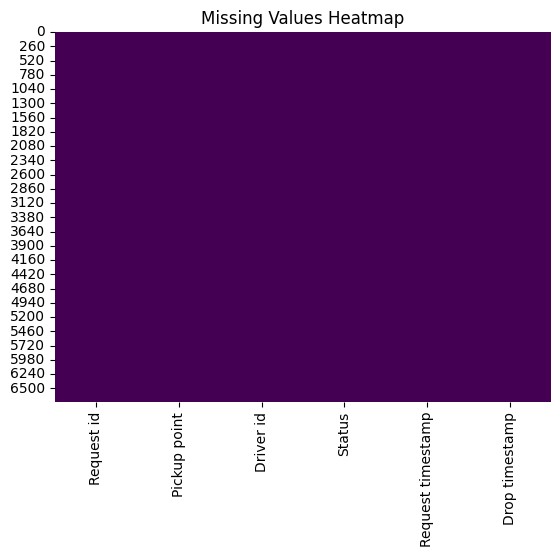

In [3]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

Drop timestamp contains null values corresponding to uncompleted rides.


In [4]:
df["Request timestamp"] = pd.to_datetime(df["Request timestamp"], errors="coerce")
df["Drop timestamp"] = pd.to_datetime(df["Drop timestamp"], errors="coerce")

C:\Users\libin\AppData\Local\Temp\ipykernel_20776\3900659100.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Request timestamp"] = pd.to_datetime(df["Request timestamp"], errors="coerce")
C:\Users\libin\AppData\Local\Temp\ipykernel_20776\3900659100.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Drop timestamp"] = pd.to_datetime(df["Drop timestamp"], errors="coerce")


In [5]:
df["Hour"] = df["Request timestamp"].dt.hour

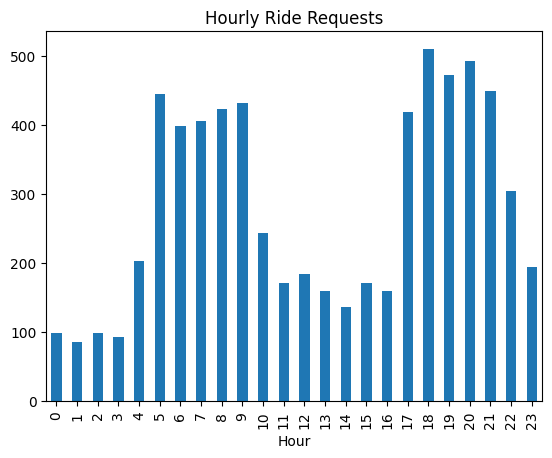

In [6]:
df["Hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Hourly Ride Requests")
plt.show()

In [10]:
def time_slot(Hour):
    if 0 <= Hour < 4 :
        return "Late Night"
    elif 4 <= Hour < 8:
        return "Early Morning"
    elif 8 <= Hour < 12:
        return "Morning"
    elif 12 <= Hour < 16:
        return "Afternoon"
    elif 16 <= Hour < 20:
        return "Evening"
    elif 20 <= Hour < 24:
        return "Night"
df['time slot'] = df['Hour'].apply(time_slot)

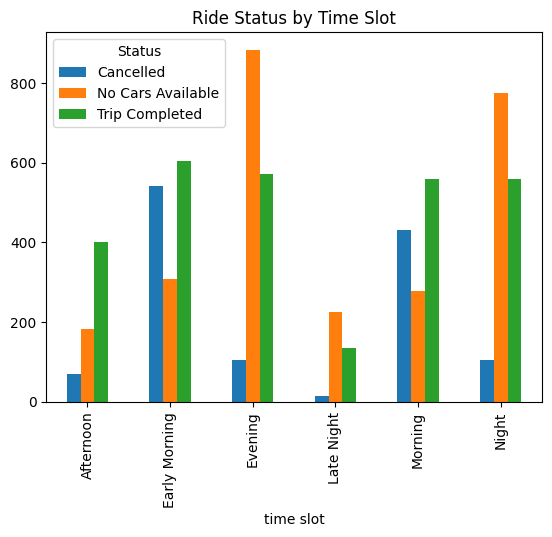

In [11]:
pd.crosstab(df["time slot"], df["Status"]).plot(kind="bar")
plt.title("Ride Status by Time Slot")
plt.show()

In [12]:
df.to_excel("uber_cleaned.xlsx", index=False)

## Key Findings

- Evening peak (5–9 PM) shows highest No Cars Available.
- Morning peak shows highest cancellation rates.
- Demand peaks at 6 PM and 8 PM.

- Implement dynamic pricing during evening peak.
- Introduce completion incentives during morning peak.
- Optimize driver allocation during high-demand windows.